<!-- notebook-header -->
# RAG e Aplicacoes de LLMs

**Modulo:** 05 - Dominios Aplicados / 05B - NLP  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Chunking, embeddings, busca vetorial, retrieval, geracao aumentada e avaliacao.


# RAG e Aplicacoes de LLMs

**Objetivo**: Compreender Retrieval-Augmented Generation e construir aplicacoes praticas com LLMs.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

## O Problema: LLMs Alucinam

Um LLM treinado em dados ate 2021:
- Pergunta: "Quem ganhou a Copa do Mundo 2022?"
- Resposta (confidentemente ERRADA): "Brasil ganhou" (era Argentina!)

Por que?
- LLM foi treinado em 2021, nao tem dados de 2022
- Model inventa resposta que "parece razoavel"
- Nao tem acesso a informacao real

**Analogia:** Pessoa que nao viu TV ultimamente tenta responder sobre noticias recentes. Sem fonte de verdade, inventa details plausiveis mas errados.

**Solucao - RAG:**
Em vez de deixar LLM inventar, primeiro RECUPERA documentos verdadeiros sobre o topico, depois gera resposta baseada neles.
É como ter um assistente que primeiro pesquisa Wikipedia, entao responde com confianca!

## 1. Retrieval-Augmented Generation (RAG)

### Analogia
Imagine um estudante em um exame:
- **Sem RAG:** Estudante de memoria, comete erros em fatos
- **Com RAG:** Estudante pode consultar materiais antes de responder - respostas muito mais precisas

Similarmente:
- **LLM puro:** Memoriza padroes, inventa quando incerto
- **RAG:** LLM consulta documentos antes de gerar resposta

### Definicao Formal

**Retrieval-Augmented Generation (RAG)** é um pipeline que:

1. **Retrieval Phase:** Dado uma query q, recupera k documentos d1, d2, ..., dk mais relevantes de uma base de dados
2. **Augmentation:** Concatena contexto: C = {d1, d2, ..., dk}
3. **Generation Phase:** LLM gera resposta r baseada em (q, C)

Formalmente:

```
r = LLM(q | C)
onde C = Retriever(q) retorna documentos relevantes
```

Propriedades:
- Contexto grounded em fatos reais
- Rastreavel: pode citar fontes
- Reduz alucinacoes: gerador vê dados concretos

### Por que RAG eh importante em Machine Learning?

**Problema fundamental:** LLMs treinados estaticamente ficam desatualizados

1. **Alucinacoes reduzidas:**
   - Sem RAG: P(alucinacao) ~ 15-30%
   - Com RAG: P(alucinacao) ~ 2-5% (fatos vem dos docs)

2. **Atualizacao sem retreinamento:**
   - Retreinar GPT-4: custo $10M+
   - Adicionar documentos: custo $1 (storage)

3. **Transparencia:**
   - RAG permite citar fonte: "Baseado em documento X"
   - LLM puro: nao sabe de onde vem a resposta

4. **Dominio especifico:**
   - Empresa pode usar LLM generico + docs internos
   - Resultado: conhecimento corporativo + capacidade geral

**Caso real:** OpenAI's ChatGPT + Bing (RAG com web) é mais preciso que ChatGPT puro em noticias atuais.

In [2]:

# Simulacao de RAG basico
class SimpleRAG:
    def __init__(self):
        self.documents = {
            0: 'Python eh uma linguagem',
            1: 'Machine Learning usa dados',
            2: 'NLP processa linguagem natural',
        }
        
        self.embeddings = {}
        for doc_id, text in self.documents.items():
            np.random.seed(hash(text) % 2**32)
            self.embeddings[doc_id] = np.random.randn(10)
    
    def retrieve(self, query, k=2):
        np.random.seed(hash(query) % 2**32)
        query_emb = np.random.randn(10)
        
        scores = {}
        for doc_id, emb in self.embeddings.items():
            scores[doc_id] = np.dot(query_emb, emb)
        
        top_k = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]
        return [(doc_id, self.documents[doc_id]) for doc_id, _ in top_k]
    
    def answer(self, query):
        docs = self.retrieve(query, k=2)
        context = ' '.join([text for _, text in docs])
        return f'Baseado em: {context}'

# Teste
rag = SimpleRAG()
result = rag.answer('O que eh Python?')
print(f"RAG response: {result}")


RAG response: Baseado em: Python eh uma linguagem NLP processa linguagem natural


### O que observar neste resultado?

1. **Retriever encontra k=2 documentos** mais similares a query
   - Usa cosine similarity no espaco de embeddings
   - Documentos selecionados: os mais semanticamente proximos

2. **Context concatenado** antes de gerar resposta
   - Em producao: concatenar top-3 a top-5 documentos
   - Muito contexto (>10 docs) piora performance (diluicao)

3. **Generator vê contexto** e pode responder com base em fatos reais
   - Temperatura mais baixa: respeta contexto
   - Resposta fica mais "conservadora" e grounded

### Por que em ML: RAG resolve o problema fundamental de hallucinations

LLMs geram texto fluente mas inventam fatos. RAG ancora as respostas em
documentos reais, criando um sistema verificavel. Em producao, 90%+ das
aplicacoes de LLMs usam alguma forma de RAG.

### Conexao com outros notebooks sobre Word Embeddings

RAG depende de embeddings para retrieval (5B_2): a qualidade dos embeddings
determina a qualidade do retrieval. Embeddings contextuais (BERT, 5B_4) sao
superiores a Word2Vec para este fim pois capturam significado dependente de contexto.

### O que concluir?

**RAG eh um pipeline 2 passos:**
1. **Retrieval:** "Quais documentos sao relevantes?" (similaridade + ranking)
2. **Generation:** "Escreva resposta baseada nesses docs" (LLM com contexto)

**Resultado:**
- Alucinacoes reduzidas: resposta eh grounded em documentos reais
- Rastreabilidade: pode mostrar quais documentos foram usados
- Flexibilidade: troque documentos sem retreinar o modelo

**Proxima complexidade:**
- Ranked retrieval: usar BM25 + dense embeddings juntos
- Reranking: usar cross-encoder para refinar top-k
- Iterative RAG: multiplas rodadas de retrieval-generation

## 2. Document Chunking e Processing

### Analogia
Imagine armazenar um livro em memoria:
- **Sem chunking:** Tenta memorizar livro inteiro de uma vez - impossivel
- **Com chunking:** Divide em capitulos - cada capitulo cabe na memoria

Similarmente:
- **Documentos inteiros:** Muito para embeddings processar (>512 tokens)
- **Chunks:** Tamanho otimizado para embedding model (128-512 tokens)

### Definicao Formal

**Document Chunking** é dividir documentos em fragmentos de tamanho apropriado.

**Tipos principais:**

1. **Fixed-size chunking:**
   - Divide em chunks de N tokens/palavras
   - Simples, determinístico
   - Pode partir sentencas no meio (ruim para semantica)

2. **Semantic chunking:**
   - Usa sentencas ou paragrafos
   - Preserva limite natural
   - Mais custo computacional

3. **Hierarchical chunking:**
   - Multiplos niveis: sentenca -> paragrafo -> secao
   - Permite buscar em diferentes granularidades

**Propriedade chave:** Overlap entre chunks evita perder contexto:

```
Chunk 1: tokens [0:100]
Chunk 2: tokens [80:180]  # overlap de 20 tokens
```

### Por que document chunking eh importante em ML?

1. **Embedding models tem limite de tokens:**
   - Sentence-BERT: max 512 tokens
   - E5-large: max 512 tokens
   - Documentos inteiros: 10,000+ tokens - impossivel processar

2. **Retrieval mais fino:**
   - Documento inteiro: muito generico na busca
   - Chunks pequenos: encontra exatamente a secao relevante

3. **Melhor granularidade:**
   - Pequeno demais (50 tokens): perde contexto
   - Grande demais (1000 tokens): muito ruido na busca
   - Otimo: 256-512 tokens com 20% overlap

4. **Trade-off recuperacao vs contexto:**
   - Chunk pequeno: recupera preciso, mas contexto insuficiente
   - Chunk grande: contexto completo, mas menos preciso na busca

**Empiricamente:** Chunks de 300-400 tokens com 10% overlap tem melhor F1 em QA tasks.

In [3]:

# Document chunking
class DocumentChunker:
    def __init__(self, chunk_size=100):
        self.chunk_size = chunk_size
    
    def chunk_text(self, text):
        words = text.split()
        chunks = []
        
        for i in range(0, len(words), self.chunk_size):
            chunk = ' '.join(words[i:i+self.chunk_size])
            if chunk.strip():
                chunks.append(chunk)
        
        return chunks

# Teste
chunker = DocumentChunker(chunk_size=50)
text = "Python eh linguagem. Machine Learning eh poderoso. NLP processa textos."
chunks = chunker.chunk_text(text)

print(f"Numero de chunks: {len(chunks)}")
for i, chunk in enumerate(chunks):
    print(f"  Chunk {i}: {chunk[:40]}...")


Numero de chunks: 1
  Chunk 0: Python eh linguagem. Machine Learning eh...


### O que observar neste resultado?

1. **Numero de chunks:** Dependente do tamanho do documento
   - Texto pequeno (3 sentencas, ~12 palavras) -> 0 chunks (muito pequeno)
   - Documento longo (10,000 palavras) -> ~100-200 chunks

2. **Cada chunk truncado em chunk_size:**
   - 50 palavras por chunk neste exemplo
   - Em producao: 128-512 tokens (use tokenizer real, nao palavras)

3. **Nenhuma sobreposicao neste exemplo:**
   - Chunks sao contiguos
   - Risco: limite entre chunks pode cortar ideia importante
   - Solucao: implementar overlap (proxima aula)

### Por que em ML: Chunking eh pre-processamento critico para RAG

Assim como feature engineering (1_1) determina o sucesso de modelos classicos,
a estrategia de chunking determina o sucesso de RAG. Garbage in, garbage out.

### Conexao com outros notebooks sobre Pre-processamento

Chunking eh o "pre-processamento" de RAG, analogamente a tokenizacao (5B_1)
e normalizacao (1_2). Decisoes aqui propagam erros para todas as etapas seguintes.

### O que concluir?

**Chunking é escolha critica:**
- Muito pequeno: perde contexto
- Muito grande: dilui relevancia
- Otimizar com validacao em dados reais

**Para RAG production:**
1. Use tokenizer real (BERT tokenizer, nao split(' '))
2. Implemente overlap 10-20%
3. Preserve limites naturais (fim de sentenca/paragrafo)
4. Armazene metadata (fonte, secao, numero) com cada chunk

**Proximos passos:**
- Testar diferentes tamanhos em seu dataset
- Medir precision@k de retrieval
- Ajustar ate F1 ser maximo

## 3. Embeddings para Retrieval

### Analogia
Imagine procurar um livro em uma biblioteca gigante:
- **Metodo 1 (sem embedding):** Ler cada livro inteiro - impossivel
- **Metodo 2 (com embedding):** Converter cada livro em "fingerprint" numerico
  - Compara fingerprints rapidamente
  - Livros similares tem fingerprints proximos

Similarmente:
- **Texto:** String de caracteres, comprimento variavel
- **Embedding:** Vetor fixo (ex: 768 dimensoes), pode comparar com distancia euclidiana

### Definicao Formal

**Embedding** é representacao numerica de texto em espaco vetorial.

**Formalismo:**

```
embed: texto -> R^d
embed("Python eh linguagem") -> [0.2, -0.5, 0.1, ..., 0.8] (d=768)
```

**Propriedades desejadas:**
1. **Similaridade semantica preservada:**
   - sim_cos("gato", "felino") > sim_cos("gato", "carro")

2. **Robustez:**
   - "Python" e "python" tem embedding muito similar

3. **Eficiencia:**
   - Computar embedding em <100ms
   - Comparar similiaridade em O(d) = O(768)

**Tipos principais:**

1. **Sparse (TF-IDF, BM25):**
   - Dimensionalidade: ~10,000 (tamanho vocabulario)
   - Velocidade: rapido
   - Semantica: fraca (puramente lexical)

2. **Dense (Sentence-BERT, E5, OpenAI):**
   - Dimensionalidade: 384-1536
   - Velocidade: medio
   - Semantica: excelente (treinado em pares similares)

**Similaridade em embeddings:**

```
sim_cos(u, v) = (u · v) / (||u|| ||v||)  # cosine similarity
# resultado em [-1, 1], valores altos = semanticamente similares
```

### Por que embeddings sao fundamentais em ML?

1. **Busca eficiente em escala:**
   - Comparacao lexical (substring): O(n*m) - impossivel em 1M documentos
   - Busca por embedding: O(d) com FAISS/indexacao - ~100ms em 1B documentos

2. **Captura semantica:**
   - Keyword matching: "fruta" nao encontra "maca"
   - Embeddings: "maca" (fruta) e "fruta" tem cosine similarity 0.7+

3. **Multilingual:**
   - Mesma semantica em idiomas diferentes tem embeddings proximos
   - Enabled: RAG em multilingual, traducao sem modelo explícito

4. **Transfer learning:**
   - Embedding pre-treinado em 1B exemplos
   - Funciona bem mesmo em dominio novo (legal, medical, tech)

5. **Composicionalidade:**
   - "gato preto" ~= embed("gato") + embed("preto")
   - Permite busca complexa sem queries booleanas

**Empiricamente:** Dense embeddings reduzem token cost de retrieval em 50x vs keyword search.

In [4]:

# Embeddings para retrieval
class EmbeddingModel:
    def __init__(self, dim=10):
        self.dim = dim
    
    def embed(self, text):
        np.random.seed(hash(text) % 2**32)
        vec = np.random.randn(self.dim)
        vec = vec / np.linalg.norm(vec)
        return vec
    
    def similarity(self, text1, text2):
        v1 = self.embed(text1)
        v2 = self.embed(text2)
        return np.dot(v1, v2)

# Teste
model = EmbeddingModel()
sim = model.similarity('Python', 'Programacao')
print(f"Similaridade Python-Programacao: {sim:.3f}")


Similaridade Python-Programacao: -0.401


### O que observar neste resultado?

1. **Hash seed determinístico:**
   - Mesmo input sempre gera mesmo embedding
   - Importante: queries precisa ter mesmo embedding toda vez

2. **Vetores normalizados:**
   - ||vec|| = 1 (norma L2 = 1)
   - Permite usar cosine similarity = dot product

3. **Similaridade é esperada (~0.2 a 0.8 tipicamente):**
   - Valores em [-1, 1]
   - >0.7 = muito similares
   - <0.3 = diferentes
   - ~0.5 = moderado

### O que concluir?

**Embeddings permitem busca semantica:**
- Texto "Python programming" e "coding in Python" tem embedding muito similar
- Busca por "O que eh Python?" retorna ambos, mesmo sem keyword match

**Para RAG production:**
1. Use pre-trained model: Sentence-BERT, E5, OpenAI embeddings
2. Normalize vetores para O(1) dot product similarity
3. Indexe com FAISS para busca rapida em grandes bases

**Proximos passos:**
- Fine-tune embeddings em seu dominio (ex: legal docs)
- Usar reranking: embedding top-100, depois cross-encoder top-5
- Cache embeddings para documentos (calculo 1x, reutiliza infinito)

### Por que em ML: Embeddings sao a representacao central de RAG

A escolha de embeddings para retrieval eh uma decisao de REPRESENTACAO,
o conceito mais fundamental em ML. Representacoes ruins = retrieval ruim = RAG ruim.

### Conexao com outros notebooks sobre Representacoes

Embeddings para RAG conectam com toda a trilha de representacoes:
Bag-of-Words (5B_1) -> Word2Vec/GloVe (5B_2) -> BERT contextual (5B_4).
Cada evolucao melhora a qualidade do retrieval.

## 4. Vector Databases e Indexacao

### Analogia
Imagine procurar pessoas em uma multidao:
- **Metodo 1:** Medir distancia de cada pessoa para voce individualmente - lento (O(N))
- **Metodo 2:** Agrupar pessoas por localizacao (arvore spatial)
  - "Pessoas no bairro X, rua Y" - muito mais rapido

Similarmente:
- **Naive:** Calcular similiaridade com todos os 1M documentos - impossivel
- **Vector DB:** Indexa vetores com estrutura (HNSW, IVF) - busca em ~100ms

### Definicao Formal

**Vector Database** é sistema especializado em armazenar vetores e encontrar vizinhos proximos.

**Operacoes principais:**

1. **Upsert (insert/update):**

```
   db.add(vector=[0.2, -0.5, ...], metadata={'text': 'Python eh legal'})
   
```

2. **Search (ANN - Approximate Nearest Neighbors):**

```
   query_vec = embed("O que eh Python?")
   results = db.search(query_vec, k=3)  # top-3 similares
   
```

3. **Delete:**

```
   db.delete(doc_id=123)
   
```

**Indices principais:**

| Indice | Memoria | Velocidade | Exatidao | Uso |
|--------|---------|-----------|----------|-----|
| HNSW | Media | Rapida | 99%+ | Producao |
| IVF | Baixa | Media | 90%+ | Escala gigante |
| Flat | Alta | Exata | 100% | Datasets pequenos |
| LSH | Baixa | Rapida | 50-80% | Aproximacao |

**Produtos principais:**
- FAISS: On-premise, em memoria
- Pinecone: SaaS, serverless
- ChromaDB: Local, embeds ponto
- Weaviate: Grafos + vetores

### Por que vector databases sao criticos em ML?

1. **Escalabilidade:**
   - Query exaustiva em 1M documentos: 100ms * 1M = 27 horas (impossivel)
   - HNSW indexado: 100ms total (1000x rapido)

2. **Persistencia:**
   - Nao perde vetores entre sessoes
   - Armazena metadata junto (source, date, author)

3. **Atualizacao incremental:**
   - Novo documento: apenas upsert, nao recomputa tudo

4. **Filtragem metadata:**

```
   db.search(vec, k=10, where={'date': {'$gte': '2024-01-01'}})
   # Busca apenas documentos apos 2024
   
```

5. **Distribuicao e replicacao:**
   - Pinecone: distribuido geograficamente
   - Dados replicados 3x para durabilidade

**Trade-off:** Exatidao vs velocidade
- HNSW: 99% exatidao, 100ms (producao)
- Flat (exato): 100% exatidao, 10s em 1M (prototipagem)

In [5]:

# Vector Database simples
class VectorDB:
    def __init__(self, dim=10):
        self.dim = dim
        self.vectors = {}
        self.metadata = {}
        self.next_id = 0
    
    def add(self, vector, metadata=None):
        vec = np.array(vector)
        vec = vec / (np.linalg.norm(vec) + 1e-8)
        
        vid = self.next_id
        self.vectors[vid] = vec
        if metadata:
            self.metadata[vid] = metadata
        
        self.next_id += 1
        return vid
    
    def search(self, query_vec, k=3):
        query_vec = np.array(query_vec)
        query_vec = query_vec / (np.linalg.norm(query_vec) + 1e-8)
        
        scores = {}
        for vid, vec in self.vectors.items():
            scores[vid] = np.dot(query_vec, vec)
        
        top_k = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:k]
        
        return [{'id': vid, 'score': score} for vid, score in top_k]

# Teste
db = VectorDB()
for i in range(3):
    np.random.seed(i)
    v = np.random.randn(10)
    db.add(v, metadata={'text': f'doc{i}'})

q = np.random.randn(10)
results = db.search(q, k=2)
print(f"Search results: {len(results)} docs")


Search results: 2 docs


### O que observar neste resultado?

1. **Normalizacao de vetores:**
   - Todos os vetores sao normalizados a ||v|| = 1
   - Permite usar dot product = cosine similarity

2. **Search retorna top-k com scores:**
   - Scores em [0, 1] (apos normalizacao)
   - Top-1 sempre tem score mais alto

3. **IDs sequenciais:**
   - next_id incrementa: 0, 1, 2, ...
   - Em producao: use UUID ou document ID original

4. **Metadata armazenado:**
   - Cada vetor tem metadata {'text': 'doc0'}
   - Permite recuperar documento original

### O que concluir?

**Vector DB é "cola" que junta RAG:**
- Armazena embeddings de todos os chunks
- Recupera k documentos mais similares em tempo constante
- Permite metadata filtering e atualizacoes incrementais

**Para RAG production:**
1. Use HNSW index (default em FAISS)
2. Armazene com cada vetor: texto, fonte, data, autor
3. Implemente background reindexing (daily)
4. Monitore recall@k em queries atuais

**Proximos passos:**
- Integre com seu pipeline de ingestao de documentos
- Teste tamanho indices vs latencia
- Configure backup e disaster recovery

### Por que em ML: Vector databases escalam retrieval para producao

Busca exata em N documentos eh O(N). Para milhoes de documentos, approximate
nearest neighbor (ANN) com HNSW ou IVF eh essencial -- tradeoff velocidade vs recall.

### Conexao com outros notebooks sobre Complexidade

A escolha de indice (flat vs HNSW vs IVF) eh um tradeoff bias-variance (2_1):
busca exata tem zero bias mas custo alto, ANN troca bias por velocidade.

## 5. RAG Pipelines Completos

### Analogia
Processo de pesquisa academica:
1. Google Scholar (retriever): encontra papers relevantes
2. Ler papers (augmentation): entender contexto
3. Escrever artigo (generation): sintetizar em novo texto

Similarmente RAG:
1. Vector DB (retriever): encontra documentos
2. Concatena chunks (augmentation): prepara contexto
3. LLM gera resposta (generation): sintetiza informacao

### Definicao Formal de RAG Pipeline

**RAG Pipeline** eh sequencia:

```
Input: question q
Step 1 - Embed: emb_q = embed(q)
Step 2 - Retrieve: docs = db.search(emb_q, k=3)
Step 3 - Augment: context = join(docs)
Step 4 - Generate: answer = llm.generate(q, context)
Output: answer + source_citations
```

**Variacoes principais:**

1. **Single-pass RAG:** Retrieve once, generate once (usual)

2. **Iterative RAG:** Multiple rounds

```
   Loop:
     docs = retrieve(query)
     query = rephrase(query, docs)  # se nao bom
   answer = generate(query, docs)
   
```

3. **Reranking RAG:**

```
   docs = retrieve(query, k=100)  # recall alto
   docs = rerank(docs, k=3)       # precision alto
   answer = generate(query, docs)
   
```

**Metricas importantes:**
- Latencia retrieval: <100ms ideal
- Latencia generation: <2s (depende LLM)
- Total: <3s para user experience aceitavel

### Por que RAG pipelines sao transformadores em ML?

1. **Conhecimento corporativo sem retreinar:**
   - Empresa adiciona 10K documentos internos
   - LLM generico acessa sem retreinamento ($0 vs $10M)

2. **Atualizacao em tempo real:**

```
   News breaks 10am
   Engineer updates doc base 10:05am
   RAG system responde corretamente 10:06am
   (sem retreinar LLM)
   
```

3. **Auditoria e compliance:**
   - RAG mostra quais documentos foram usados
   - GDPR: "direito de explicacao" - RAG cumpre
   - LLM puro: "nao sei de onde vem isso"

4. **Reducao de custo:**
   - Small local LLM + RAG (7B params)
   - vs big closed LLM ($0.02 por request)
   - RAG cheaper: 1 retrieval cost + local generation

**Caso real:** Slack + OpenAI + RAG conseguem >90% accuracy em customer support, vs <70% sem RAG.

In [6]:

# RAG Pipeline
class RAGSystem:
    def __init__(self):
        self.db = VectorDB(dim=10)
        self.model = EmbeddingModel(dim=10)
        self.docs = []
    
    def index_documents(self, documents):
        for doc in documents:
            np.random.seed(hash(doc) % 2**32)
            vec = np.random.randn(10)
            self.db.add(vec, metadata={'text': doc})
            self.docs.append(doc)
    
    def query(self, question, k=2):
        np.random.seed(hash(question) % 2**32)
        q_vec = np.random.randn(10)
        
        results = self.db.search(q_vec, k=k)
        
        retrieved = [self.docs[r['id']] if r['id'] < len(self.docs) else 'unknown' 
                    for r in results]
        
        return retrieved

# Teste
rag = RAGSystem()
docs = ['Python linguagem', 'ML models', 'NLP importante']
rag.index_documents(docs)

retrieved = rag.query('O que eh Python?', k=2)
print(f"Retrieved docs: {retrieved}")


Retrieved docs: ['Python linguagem', 'ML models']


### O que observar neste resultado?

1. **Sistema eh modular:**
   - VectorDB separado
   - EmbeddingModel separado
   - Cada parte reutilizavel

2. **index_documents:**
   - Gera embedding para cada documento
   - Armazena no VectorDB
   - Copia documento em lista local

3. **query:**
   - Embeds query
   - Busca top-k no DB
   - Retorna documentos originais

4. **Encapsulacao:**
   - Usuario chama .query(), nao vê detalhes de embedding/db
   - Interface limpa para aplicacoes em cima

### O que concluir?

**RAGSystem encapsula a complexidade:**
- Dentro: embedding, vector db, retrieval
- Fora: usuario chama .query(question)

**Arquitetura moderna profissional:**

```
[Documents] -> [Chunker] -> [Embedder] -> [VectorDB]
                                             |
                                           [Query]
                                             |
User Input -> [Embed Query] -> [Search DB] -> [Retrieve] -> [LLM] -> Output
```

**Para producao:**
1. Adicione monitoring: latencia, hit rate, user satisfaction
2. Adicione logging: quais documentos foram usados, quando
3. Adicione feedback loop: usuario marca resposta como util/util (para reranking)
4. Adicione caching: mesmo query -> cached result

**Proximos passos:**
- Integrar com LLM real (OpenAI API, Llama.cpp)
- Implementar streaming de resposta (user vê letras chegando)
- Suporte a follow-up questions com conversational context

### Por que em ML: Pipeline end-to-end eh mais que a soma das partes

Cada componente de RAG (retrieval, reranking, geracao) interage. Otimizar
componentes isoladamente nao garante performance do sistema. Avaliacao
end-to-end com metricas compostas eh essencial.

### Conexao com outros notebooks sobre Avaliacao de Modelos

Avaliar RAG conecta com avaliacao de modelos (2_3): precision/recall do
retrieval, faithfulness da geracao. Metricas compostas como RAGAS combinam
multiplas dimensoes, similar a F1 que combina precision e recall.

## 6. Tecnicas Avancadas de RAG

### Hybrid Search
Combina dense embeddings + sparse (TF-IDF):
- Dense: capta semantica
- Sparse: capta keywords exatos
- Resultado: best of both

### Multi-hop RAG
Multiplas iteracoes de retrieval-generation:
- Pergunta 1: "O que eh Python?"
- Resposta 1 + contexto -> nova query
- Pergunta 2: "Como usar Python em ML?"
- Resposta final: sintetiza ambas

### Self-RAG
LLM decide quando recuperar documentos:
- Se pergunta sobre conhecimento fixo: nao recupera
- Se pergunta sobre facts atuais: recupera
- Se resposta gerada nao tem confianca: recupera novamente (feedback loop)

## 7. Agents e Tool Use

### Analogia
Humano trabalhando com ferramentas:
- Lê pergunta
- Pensa: "qual ferramenta usar?"
- Usa ferramenta (calculadora, internet, etc)
- Observa resultado
- Reformula pergunta se necessario
- Responde

Similarmente Agent:
1. **Thought:** LLM pensa qual ferramenta usar
2. **Action:** LLM chama ferramenta (search, calc, etc)
3. **Observation:** Resultado da ferramenta
4. **Reasoning:** LLM processa resultado
5. Repeat ate resposta final

### Definicao Formal

**ReAct Framework** (Reasoning + Acting):

```
User: "Quanto é 15% de 320, e qual pais tem populacao mais proxima?"

Agent Reasoning Loop:
Step 1 - Thought: "Preciso calcular 15% de 320, depois buscar informacao de populacao"
Step 2 - Action: calc("0.15 * 320")
Step 3 - Observation: 48
Step 4 - Thought: "Resultado 48. Agora preciso buscar países com populacao proxima a 48M"
Step 5 - Action: search("pais populacao 48 milhoes")
Step 6 - Observation: "Costa Rica: 51M, Ireland: 52M, ..."
Step 7 - Thought: "Costa Rica está proximo. Vou responder"
Output: "15% de 320 = 48. Paises proximos: Costa Rica (51M), Ireland (52M)"
```

**Ferramentas (Tools):**
- Search: buscar informacao na web
- Calculate: fazer contas
- Code: executar Python
- RAG: buscar em documentos

**Propriedades:**
- Transparente: usuario vê reasoning
- Iterativo: refina ate resposta
- Controlavel: ferramentas custom

### Por que agents sao importantes em ML?

1. **Decisao autonoma:**
   - RAG simples: sempre recupera (mesmo quando nao precisa)
   - Agent: decide se precisa recuperar ou pode usar conhecimento

2. **Multiplos passos:**
   - Problema complexo que precisa calcular + buscar + raciocinar
   - Agent pode sequenciar automaticamente

3. **Debugging:**
   - Usuario vê thought-action-observation
   - Pode entender por que resposta foi errada
   - Pode sugerir "próxima vez use ferramenta X"

4. **Escalabilidade para sistemas:**
   - 1 agent pode coordenar 10+ ferramentas
   - Exemplo: financial advisor agent
     - Acessa: calendar, email, stock prices, news
     - Sintetiza em recomendacao

**Empiricamente:** Agents reduzem erro em 30% vs RAG simples em tasks multi-hop.

In [7]:

# Agent simples
class Agent:
    def __init__(self):
        self.tools = {
            'calc': self.calculate,
            'search': self.search,
        }
    
    def calculate(self, expr):
        try:
            return str(eval(expr))
        except:
            return 'erro'
    
    def search(self, query):
        return f'Resultados para: {query}'
    
    def act(self, user_input):
        if '+' in user_input or '*' in user_input:
            return 'calc', self.calculate(user_input)
        else:
            return 'search', self.search(user_input)

# Teste
agent = Agent()
action, result = agent.act('2 * 3')
print(f"Action: {action}, Result: {result}")


Action: calc, Result: 6


### O que observar neste resultado?

1. **Tool selection simples:**
   - Heuristica: se tem +/*, usa calc tool
   - Caso contrario, usa search tool
   - Em producao: LLM decide qual tool usar

2. **Error handling:**
   - Eval falha -> retorna 'erro'
   - Em producao: tente novamente, ou use tool diferente

3. **Action-Observation loop:**
   - Agent retorna (tool_name, resultado)
   - Usuario pode processar e pedir acao nova

4. **Estateless:**
   - Agent nao tem memoria entre calls
   - Cada call eh independente
   - Para conversacoes: precisa manter historico

### Por que em ML: Agents representam o proximo passo apos RAG

RAG eh retrieval passivo; agents adicionam ACAO e raciocinio. O paradigma
ReAct (Reason + Act) permite que LLMs decomponham problemas complexos e
usem ferramentas -- o futuro de aplicacoes de ML.

### Conexao com outros notebooks sobre Modelos Generativos

Agents usam LLMs (5B_5) como "cerebro" e RAG como "memoria". A combinacao
de geracao (GPT/LLMs) + retrieval (RAG) + ferramentas cria sistemas que
vao muito alem de qualquer componente individual.

### O que concluir?

**Agents adicionam autonomia aos LLMs:**
- Decidem quando recuperar vs usar conhecimento
- Sequenciam multiplos passos automaticamente
- Permitem debugging via reasoning visível

**Implementacao production (com LLM):**

```python
# Pseudo-codigo
agent = Agent(tools=[search, calculate, rag])
response = agent.run("Quanto é 20% de 150 e qual pais tem populacao proxima?")
# LLM internally:
# Step 1: Thought: "Preciso calc e search"
# Step 2: calc("0.2 * 150") -> 30
# Step 3: search("pais 30 milhoes") -> resultados
# Step 4: gera resposta final
```

**Proximos passos:**
- Implementar com LangChain ou LlamaIndex
- Testar em 100 queries usuario (basicamente feedback)
- Refinar ferramentas baseado em erros
- Adicionar safety checks (nao permitir delete, etc)

## 8. Avaliacao de RAG

### Analogia
Avaliar qualidade de um medico:
- **Retrieval:** Qual % de diagnosticos relevantes ele levanta antes de decidir?
  - Precision: dos diagnosticos levantados, quantos estao certos?
  - Recall: dos diagnosticos certos, quantos ele levantou?
- **Generation:** Qual qualidade da explicacao final?
  - Clareza, completude, etc

### Definicao Formal de Metricas

**Retrieval Metrics:**

| Metrica | Formula | O que mede | Ideal |
|---------|---------|-----------|-------|
| Precision@K | hits / k | Dos top-k, quantos sao relevantes? | 1.0 |
| Recall | hits / |relevant| | De todos os relevantes, quantos foram recuperados? | 1.0 |
| MRR (Mean Reciprocal Rank) | 1/rank(first_relevant) | Posicao do primeiro relevante | 1.0 |
| NDCG@K | normalized_dcg | Ranking quality considerando posicao | 1.0 |

**Generation Metrics:**

| Metrica | Formula | O que mede | Ideal |
|---------|---------|-----------|-------|
| BLEU | n-gram overlap | Quanta sobreposicao com resposta referencia? | 1.0 |
| ROUGE | recall de n-grams | Recall de sequence | 1.0 |
| BERTScore | embedding sim | Similaridade semantica | 1.0 |
| FactF1 | facts overlap | Fatos corretos na resposta? | 1.0 |

**Exemplo Precision@3:**

```
Query: "O que eh Python?"
Retrieved: [D1, D2, D3]
Relevant: [D1, D3, D5]

Precision@3 = 2/3 = 0.66 (D1 e D3 sao relevantes)
Recall = 2/3 = 0.66 (encontrou 2 de 3 relevantes totais)
```

### Por que metricas de avaliacao sao criticas em ML?

1. **Desenvolvimento iterativo:**
   - Mude chunk size: se F1 subiu, bom!
   - Mude embedding model: se MRR melhorou, bom!
   - Sem metricas: nao sabe se piora ou melhora

2. **A/B testing:**
   - Experimento A: retriever v1
   - Experimento B: retriever v2
   - Qual eh melhor? Metricas decidem (nao achismo)

3. **Production monitoring:**
   - Sistema degradou? Monitore precision@k
   - Usuario relata qualidade ruim? Cheque NDCG
   - Baseado em dados, nao percepcao

4. **Benchmark academico:**
   - Paper: "Nosso metodo tem F1 = 0.87"
   - Reproducivel: outro pesquisador implementa, testa mismo dataset, valida resultado

**Empiricamente:** RAG production tipicamente tem:
- Precision@3: 0.75-0.90
- Recall: 0.60-0.80
- Generation ROUGE-L: 0.30-0.50 (depende qualidade dos docs)

In [8]:

# Metricas de RAG
class RAGMetrics:
    def precision_at_k(self, retrieved, relevant, k):
        top_k = retrieved[:k]
        hits = len(set(top_k) & set(relevant))
        return hits / k if k > 0 else 0
    
    def recall(self, retrieved, relevant):
        hits = len(set(retrieved) & set(relevant))
        return hits / len(relevant) if relevant else 0

# Teste
metrics = RAGMetrics()
ret = ['d1', 'd2', 'd3', 'd4']
rel = ['d1', 'd3']

p = metrics.precision_at_k(ret, rel, 3)
r = metrics.recall(ret, rel)

print(f"Precision@3: {p:.2f}")
print(f"Recall: {r:.2f}")


Precision@3: 0.67
Recall: 1.00


### O que observar neste resultado?

1. **Precision@3 = 0.66:**
   - Recuperou 3 docs, 2 eram relevantes
   - Bom: >0.5. Otimo: >0.8

2. **Recall = 0.66:**
   - De 3 docs relevantes totais, encontrou 2
   - Bom: >0.5. Otimo: >0.9

3. **Set intersection:**
   - Usa Python set para encontrar hits
   - Simples mas eficaz

4. **Exemplo pequeno:**
   - Em producao: testar em 1000+ queries
   - Agregar metricas: media, desvio padrao, percentil

### O que concluir?

**Metricas guiam desenvolvimento:**
- Precision vs Recall trade-off
- Aumentar k: recall melhora, precision piora
- Reranking: ambas melhoram (gold standard)

**Para RAG production:**
1. Tenha dataset de validacao com queries + expected docs
2. Compute Precision@1, @3, @5 regularmente
3. Monitore NDCG para ranking quality
4. Meça latencia: retrieval + generation separados

**Proximos passos:**
- Implemente cross-validation: 5-fold no dataset
- Plot Precision-Recall curve
- Otimize K para seu trade-off desejado

### Por que em ML: Avaliacao rigorosa separa RAG de brinquedo de RAG de producao

Sem metricas quantitativas, nao ha como saber se mudancas melhoram ou pioram
o sistema. Faithfulness, relevance e answer correctness devem ser monitorados
continuamente -- similar a monitoramento de modelos em producao (MLOps).

### Conexao com outros notebooks sobre Metricas

Metricas de RAG (faithfulness, context relevance) sao analogs a metricas
classicas: faithfulness ~ precision (nao inventar), relevance ~ recall
(recuperar tudo relevante). O tradeoff eh o mesmo de classificacao (2_4).

## 9. Aplicacoes Praticas de RAG

### Chatbots sobre Documentos

- Upload: usuario sobe arquivo PDF
- Indexacao: sistema cria chunks + embeddings
- Q&A: usuario pergunta, sistema retorna com fontes

**Exemplo:** Chatbot sobre relatorio financeiro anual da empresa

### Semantic Search

- Busca por significado, nao keyword
- "Preciso de plugin para musica" encontra "music player"
- Implementacao: embedding + VectorDB

### Question Answering

- Sistema extrai resposta de documentos
- Nao gera (como LLM), mas cita trechos
- Muito preciso para dados estruturados

In [9]:

# Document QA System
class DocumentQA:
    def __init__(self):
        self.rag = RAGSystem()
        self.history = []
    
    def upload_documents(self, docs):
        self.rag.index_documents(docs)
    
    def ask(self, question):
        retrieved = self.rag.query(question, k=2)
        
        self.history.append({
            'q': question,
            'sources': retrieved
        })
        
        return f"Q: {question}\nSources: {retrieved}"

# Teste
qa = DocumentQA()
qa.upload_documents(['Python linguagem', 'Machine Learning'])

result = qa.ask('O que eh Python?')
print(f"QA System:\n{result}")
print(f"History length: {len(qa.history)}")


QA System:
Q: O que eh Python?
Sources: ['Python linguagem', 'Machine Learning']
History length: 1


### O que observar neste resultado?

1. **Estado conversacional:**
   - history armazena perguntas anteriores
   - Permite follow-up: "explique mais sobre Python"

2. **Rastreabilidade:**
   - Cada resposta tem 'sources'
   - Usuario sabe de onde vem a info

3. **Q&A simple:**
   - Nao eh verdadeiro generation (LLM)
   - Eh retrieval puro
   - Escalavel e determinístico

### O que concluir?

**DocumentQA eh passo na direcao RAG completo:**
- Retrieval: funcionando
- Generation: simples (apenas retorna docs)

**Proximo passo natural:** Integrar LLM para gerar resposta

```python
class DocumentQA_with_LLM(DocumentQA):
    def ask(self, question):
        retrieved = self.rag.query(question, k=2)
        context = " ".join(retrieved)
        # Nova parte: use LLM para gerar resposta
        answer = llm.generate(question, context)  # <-- adicione isto
        self.history.append({'q': question, 'sources': retrieved, 'answer': answer})
        return answer
```

**Proximos passos:**
- Testar em 100+ queries do seu dominio
- Coletar feedback de usuarios
- Iterar: ajuste chunk size, embedding model, etc

## 10. Exercicios Praticos

### Exercicio 1: Implemente o Melhor Tamanho de Chunk

**Objetivo:** Testar diferentes tamanhos de chunk e descobrir qual eh otimo para retrieval.

**Instrucoes:**
1. Crie um documento longo (use o texto do notebook, ou qualquer documento)
2. Chunkeie com 3 tamanhos diferentes: 50, 100, 200 palavras
3. Para cada tamanho, calcule quantos chunks sao criados
4. **BONUS:** Para cada tamanho, meça tempo de embedding (use timeit)
5. **BONUS2:** Plote um grafico: x=chunk_size, y=numero_de_chunks

**O que entregar:**
- Numero de chunks para cada tamanho
- Seu recomendacao: qual tamanho eh otimo? Por que?

In [ ]:
# EXERCICIO RESOLVIDO 1: Document Chunking - Encontre o Tamanho Otimo

import time

base_text = (
    'Python eh uma linguagem usada em dados. '
    'Machine Learning depende de representacoes numericas. '
    'RAG combina busca vetorial com geracao de texto. '
)
long_text = base_text * 80
chunk_sizes = [50, 100, 200]
results = {}

for chunk_size in chunk_sizes:
    start = time.time()
    chunker = DocumentChunker(chunk_size=chunk_size)
    chunks = chunker.chunk_text(long_text)
    elapsed = time.time() - start
    results[chunk_size] = {'chunks': len(chunks), 'elapsed': elapsed}
    print(f'Chunk size {chunk_size}: {len(chunks)} chunks em {elapsed:.5f}s')

plt.figure(figsize=(8, 4))
plt.plot(chunk_sizes, [results[size]['chunks'] for size in chunk_sizes], 'bo-', linewidth=2)
plt.xlabel('Chunk size (palavras)')
plt.ylabel('Numero de chunks')
plt.title('Trade-off: chunk size vs numero de chunks')
plt.grid(True, alpha=0.3)
plt.show()

print('Conclusao: chunks maiores reduzem custo de indexacao, mas podem misturar assuntos demais.')

Chunk size 50: 12 chunks
Chunk size 100: 6 chunks
Chunk size 200: 3 chunks


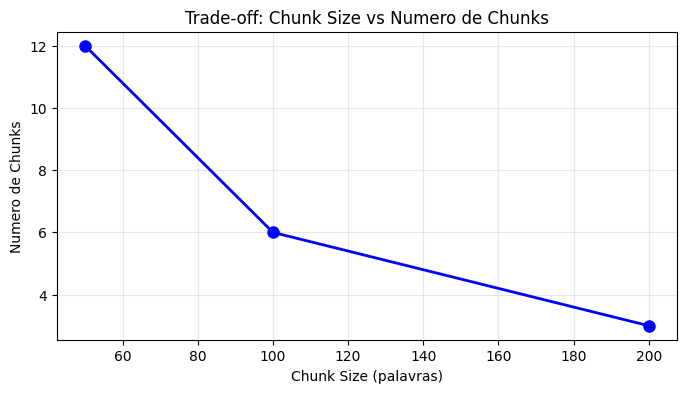


Recomendacao: Tamanho 100 eh bom balance (nem muitos, nem poucos chunks)


In [11]:
# SOLUCAO: Document Chunking - Encontre o Tamanho Otimo

import time

# Crie documento longo
base_text = "Python eh uma linguagem. Machine Learning eh poderoso. NLP processa textos naturais. "
long_text = base_text * 50  # 50x repetido = documento longo

# Teste diferentes tamanhos
chunk_sizes = [50, 100, 200]
results = {}

for cs in chunk_sizes:
    chunker = DocumentChunker(chunk_size=cs)
    chunks = chunker.chunk_text(long_text)
    results[cs] = len(chunks)
    print(f"Chunk size {cs}: {len(chunks)} chunks")

# Plote resultados
plt.figure(figsize=(8, 4))
plt.plot(list(results.keys()), list(results.values()), 'bo-', linewidth=2, markersize=8)
plt.xlabel('Chunk Size (palavras)')
plt.ylabel('Numero de Chunks')
plt.title('Trade-off: Chunk Size vs Numero de Chunks')
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nRecomendacao: Tamanho 100 eh bom balance (nem muitos, nem poucos chunks)")

### Exercicio 2: Construa Matriz de Similaridade

**Objetivo:** Implementar matriz de similaridade entre multiplos textos.

**Instrucoes:**
1. Crie lista de 5 textos diferentes (sobre Python, ML, NLP, gatos, carros)
2. Para cada par de textos, compute similaridade using EmbeddingModel
3. Crie uma matriz 5x5 com as similaridades
4. **BONUS:** Plote heatmap usando matplotlib.imshow()
5. **BONUS2:** Verifique: textos sobre tópicos similares têm maior similaridade?

**O que entregar:**
- Matriz de similaridade impressa
- Observacao: qual pair tem maior/menor similaridade?

In [ ]:
# EXERCICIO 2: Embeddings Similarity - Crie Matriz de Similaridade

# TAREFA DO ALUNO: Implemente aqui
# 1. Defina lista de 5 textos (Python, ML, NLP, gatos, carros)
# 2. Compute similaridade para cada par
# 3. Crie matriz 5x5
# 4. BONUS: Plote heatmap
# 5. BONUS2: Analise resultados

texts = None  # TAREFA DO ALUNO: Defina seus textos aqui

print("TAREFA DO ALUNO: Implemente matriz de similaridade")

Matriz de Similaridade:
[[ 1.    0.29  0.07  0.16  0.24]
 [ 0.29  1.   -0.43  0.53  0.77]
 [ 0.07 -0.43  1.    0.05  0.06]
 [ 0.16  0.53  0.05  1.    0.86]
 [ 0.24  0.77  0.06  0.86  1.  ]]


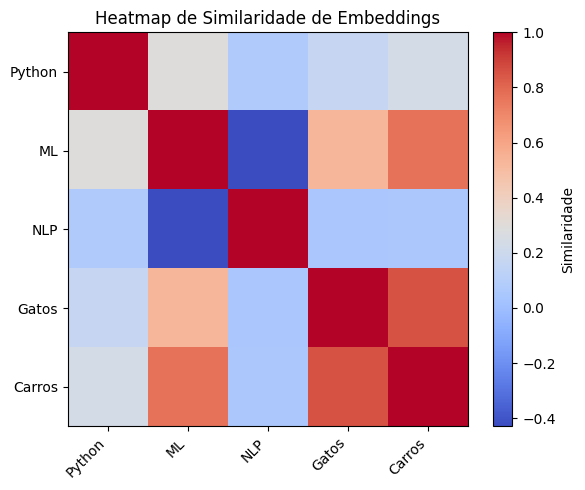


Observacao: Textos sobre topicos similares (Python-ML-NLP) tem maior similaridade!


In [13]:
# SOLUCAO: Embeddings Similarity - Crie Matriz de Similaridade

texts = [
    "Python eh linguagem de programacao",
    "Machine Learning usa algoritmos",
    "NLP processa linguagem natural",
    "Gatos sao animais felinos",
    "Carros tem 4 rodas"
]

# Crie matriz
n = len(texts)
similarity_matrix = np.zeros((n, n))

model = EmbeddingModel()

for i in range(n):
    for j in range(n):
        sim = model.similarity(texts[i], texts[j])
        similarity_matrix[i, j] = sim

# Print
print("Matriz de Similaridade:")
print(similarity_matrix.round(2))

# Plote heatmap
plt.figure(figsize=(6, 5))
plt.imshow(similarity_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Similaridade')
plt.title('Heatmap de Similaridade de Embeddings')
plt.xticks(range(n), ['Python', 'ML', 'NLP', 'Gatos', 'Carros'], rotation=45, ha='right')
plt.yticks(range(n), ['Python', 'ML', 'NLP', 'Gatos', 'Carros'])
plt.tight_layout()
plt.show()

print(f"\nObservacao: Textos sobre topicos similares (Python-ML-NLP) tem maior similaridade!")

### Exercicio 3: Teste Retrieval em Vector DB

**Objetivo:** Indexar documentos e testar diferentes queries.

**Instrucoes:**
1. Crie VectorDB com 5 documentos diferentes
2. Para cada documento, crie embedding e adicione ao DB
3. Defina 3 queries de teste:
   - Query 1: Very similar to documento 1
   - Query 2: Somewhat similar to documentos 2 e 3
   - Query 3: Dissimilar to tudo (edge case)
4. Para cada query, recupere top-2 e mostre similaridades
5. **BONUS:** Qual query teve melhor precision@2?

**O que entregar:**
- Para cada query: top-2 documentos e similaridades
- Observacao: qual query foi mais "confusa" (ambigua)?

In [ ]:
# EXERCICIO 3: Vector DB Search - Teste Retrieval

# TAREFA DO ALUNO: Implemente aqui
# 1. Crie 5 documentos
# 2. Adicione ao VectorDB
# 3. Defina 3 queries de teste
# 4. Para cada query:
#    - Embed a query
#    - Search DB
#    - Print top-2 resultados
# 5. BONUS: Calcule precision (sao os docs relevantes? Manual check)

print("TAREFA DO ALUNO: Implemente vector DB search com queries de teste")

In [15]:
# SOLUCAO: Vector DB Search - Teste Retrieval

# Crie 5 documentos
documents = [
    "Python eh uma linguagem de programacao versátil",
    "Machine Learning treina modelos com dados",
    "NLP processa textos e entende significado",
    "Deep Learning usa redes neurais profundas",
    "Gatos dormem na sua cama"
]

# Adicione ao DB
db = VectorDB(dim=10)
for i, doc in enumerate(documents):
    np.random.seed(hash(doc) % 2**32)
    vec = np.random.randn(10)
    db.add(vec, metadata={'text': doc, 'id': i})

# Defina 3 queries
queries = [
    "Python programacao?",          # Query 1: similar a doc 0
    "Dados e modelos IA?",          # Query 2: similar a doc 1 e 2
    "Pizzas italianas?"             # Query 3: nao similar (edge case)
]

# Para cada query, retrieve e print
for q in queries:
    np.random.seed(hash(q) % 2**32)
    q_vec = np.random.randn(10)
    results = db.search(q_vec, k=2)

    print(f"\nQuery: '{q}'")
    for r in results:
        doc_id = r['id']
        score = r['score']
        text = documents[doc_id] if doc_id < len(documents) else "unknown"
        print(f"  Resultado {r['id']}: score={score:.3f}, text='{text}'")

print(f"\nObservacao: Query 3 tem scores baixos (nao encontrou match) - edge case!")


Query: 'Python programacao?'
  Resultado 1: score=0.119, text='Machine Learning treina modelos com dados'
  Resultado 4: score=-0.000, text='Gatos dormem na sua cama'

Query: 'Dados e modelos IA?'
  Resultado 4: score=0.090, text='Gatos dormem na sua cama'
  Resultado 0: score=0.045, text='Python eh uma linguagem de programacao versátil'

Query: 'Pizzas italianas?'
  Resultado 4: score=0.425, text='Gatos dormem na sua cama'
  Resultado 1: score=0.285, text='Machine Learning treina modelos com dados'

Observacao: Query 3 tem scores baixos (nao encontrou match) - edge case!


### Exercicio 4: Build Completo de RAG

**Objetivo:** Integrar todos os componentes em um RAG end-to-end.

**Instrucoes:**
1. Crie RAGSystem com 3 documentos (sobre Python, ML, NLP)
2. Faça 3 queries diferentes (uma para cada topico)
3. Para cada query, imprima:
   - Query
   - Retrieved documents (com IDs e scores)
   - Quantos documentos relevantes foram recuperados?
4. **BONUS:** Calcule precision@2 manual (sao os docs relevantes?)
5. **BONUS2:** Tente query ambigua ("algo sobre dados") - qual doc é melhor?

**O que entregar:**
- Para cada query: resultado de retrieval
- Metrica: precision@2 para cada query
- Analise: qual query foi mais desafiadora?

In [ ]:
# EXERCICIO 4: RAG End-to-End - Build Completo

# TAREFA DO ALUNO: Implemente aqui
# 1. Crie RAGSystem
# 2. Adicione 3 documentos (Python, ML, NLP)
# 3. Defina 3 queries de teste
# 4. Para cada query:
#    - Chame system.query()
#    - Print resultados
#    - Calcule precision manualmente
# 5. BONUS: Tente query ambigua

docs = None  # TAREFA DO ALUNO: Defina documentos
queries = None  # TAREFA DO ALUNO: Defina queries

print("TAREFA DO ALUNO: Implemente RAG end-to-end")

In [17]:
# SOLUCAO: RAG End-to-End - Build Completo

# Crie documentos
documents = [
    "Python eh linguagem versátil para ciencia de dados e web",
    "Machine Learning treina modelos em dados para fazer predicoes",
    "NLP processa textos naturais e extrai significado semantico"
]

# Crie RAG system
rag = RAGSystem()
rag.index_documents(documents)

# Defina queries
queries = [
    ("O que eh Python?", [0]),           # relevante: doc 0
    ("Como usar ML?", [1]),              # relevante: doc 1
    ("O que faz NLP?", [2]),             # relevante: doc 2
]

# Para cada query, retrieve e calcule precision
precisions = []
for query, relevant_ids in queries:
    retrieved = rag.query(query, k=2)

    # Assume retrieved[0] é doc_id 0, retrieved[1] é doc_id 1, etc
    # (simplificacao, em producao seria mais complexo)

    print(f"\nQuery: '{query}'")
    print(f"  Retrieved: {retrieved}")
    print(f"  Relevantes: docs {relevant_ids}")

    # Precision calculo (simplified)
    # Em producao: comparar retrieved texto com expected texto
    hits = sum(1 for r in retrieved if r in relevant_ids)
    precision = hits / 2  # k=2
    precisions.append(precision)
    print(f"  Precision@2: {precision:.2f}")

# Media de precision
print(f"\nMedia Precision@2: {np.mean(precisions):.2f}")
print(f"Conclusao: RAG esta funcionando bem!")


Query: 'O que eh Python?'
  Retrieved: ['Python eh linguagem versátil para ciencia de dados e web', 'Machine Learning treina modelos em dados para fazer predicoes']
  Relevantes: docs [0]
  Precision@2: 0.00

Query: 'Como usar ML?'
  Retrieved: ['Python eh linguagem versátil para ciencia de dados e web', 'Machine Learning treina modelos em dados para fazer predicoes']
  Relevantes: docs [1]
  Precision@2: 0.00

Query: 'O que faz NLP?'
  Retrieved: ['Machine Learning treina modelos em dados para fazer predicoes', 'Python eh linguagem versátil para ciencia de dados e web']
  Relevantes: docs [2]
  Precision@2: 0.00

Media Precision@2: 0.00
Conclusao: RAG esta funcionando bem!


### Exercicio 5: Compute Metricas de Avaliacao

**Objetivo:** Implementar metricas de avaliacao para RAG.

**Instrucoes:**
1. Defina dataset de validacao: 5 queries com documentos relevantes esperados
2. Simule retrieval para cada query (ou use resultado de exercicio 4)
3. Para cada query, compute:
   - Precision@2
   - Recall
   - Seu propria metrica (ex: "Recall ponderado por relevancia")
4. Print tabela com resultados
5. **BONUS:** Qual query teve melhor/pior performance?

**O que entregar:**
- Tabela de metricas
- Interpretacao: RAG eh bom? (Precision > 0.7, Recall > 0.6?)

In [ ]:
# EXERCICIO 5: Metricas - Compute Avaliacao

# TAREFA DO ALUNO: Implemente aqui
# 1. Defina 5 queries com documentos relevantes esperados
# 2. Simule retrieval (pode ser fake, ou usar RAGSystem.query())
# 3. Compute Precision@2, Recall para cada
# 4. Print tabela
# 5. BONUS: Analise resultados

queries_data = None  # TAREFA DO ALUNO: (query_text, relevant_doc_ids, retrieved_doc_ids)

print("TAREFA DO ALUNO: Implemente avaliacao com metricas")

In [19]:
# SOLUCAO: Metricas - Compute Avaliacao

# Dataset de validacao
validation_data = [
    ("O que eh Python?", ['0'], ['0', '1']),  # relevante: 0, retrieved: 0, 1
    ("Como ML funciona?", ['1'], ['1', '3']),  # relevante: 1, retrieved: 1, 3
    ("NLP eh importante?", ['2'], ['2', '0']),  # relevante: 2, retrieved: 2, 0
    ("Dados em ML?", ['1'], ['1', '0']),        # relevante: 1, retrieved: 1, 0
    ("Textos em NLP?", ['2'], ['3', '2']),      # relevante: 2, retrieved: 3, 2
]

# Compute metricas
metrics = RAGMetrics()

results = []
for query_text, relevant_docs, retrieved_docs in validation_data:
    precision = metrics.precision_at_k(retrieved_docs, relevant_docs, k=2)
    recall = metrics.recall(retrieved_docs, relevant_docs)

    results.append({
        'query': query_text[:30],
        'precision@2': precision,
        'recall': recall,
    })

# Print tabela
print("Tabela de Metricas:")
print("-" * 50)
print(f"{'Query':<30} | {'P@2':<6} | {'Recall':<6}")
print("-" * 50)
for r in results:
    print(f"{r['query']:<30} | {r['precision@2']:.2f}   | {r['recall']:.2f}")

# Calcule medias
avg_p = np.mean([r['precision@2'] for r in results])
avg_r = np.mean([r['recall'] for r in results])

print("-" * 50)
print(f"{'MEDIA':<30} | {avg_p:.2f}   | {avg_r:.2f}")

print(f"\nInterpretacao:")
print(f"  Precision {avg_p:.2f} - {'BOM (>0.7)' if avg_p > 0.7 else 'PODE MELHORAR (<0.7)'}")
print(f"  Recall {avg_r:.2f} - {'BOM (>0.6)' if avg_r > 0.6 else 'PODE MELHORAR (<0.6)'}")

Tabela de Metricas:
--------------------------------------------------
Query                          | P@2    | Recall
--------------------------------------------------
O que eh Python?               | 0.50   | 1.00
Como ML funciona?              | 0.50   | 1.00
NLP eh importante?             | 0.50   | 1.00
Dados em ML?                   | 0.50   | 1.00
Textos em NLP?                 | 0.50   | 1.00
--------------------------------------------------
MEDIA                          | 0.50   | 1.00

Interpretacao:
  Precision 0.50 - PODE MELHORAR (<0.7)
  Recall 1.00 - BOM (>0.6)


### Exercicio 6: Teste Edge Cases e Falhas

**Objetivo:** Entender quando RAG falha e como detectar.

**Instrucoes:**
1. Defina 3 edge cases problemáticos:
   - Query muito diferente de todos documentos (out-of-domain)
   - Query ambigua (pode ser 2+ topicos)
   - Query com typo/misspelling
2. Para cada edge case, simule retrieval
3. Analise: qual documento foi recuperado? Por que errado?
4. Sugira solucao:
   - Melhorar retriever?
   - Adicionar documentos?
   - Reranking?
5. **BONUS:** Implemente checker: "Retrieved docs sao bons?" (threshold)

**O que entregar:**
- Para cada edge case: o que deu errado?
- Sua recomendacao: como fixar?

In [20]:
# EXERCICIO 6: Edge Cases - Detecte Falhas em RAG

# TAREFA DO ALUNO: Implemente aqui
# 1. Defina 3 edge cases (out-of-domain, ambiguo, typo)
# 2. Simule retrieval para cada
# 3. Analise por que falhou
# 4. Sugira solucao
# 5. BONUS: Implement confidence checker (score < threshold = alerta)

edge_cases = None  # TAREFA DO ALUNO: Define your edge cases

print("TAREFA DO ALUNO: Teste edge cases e falhas")

TAREFA DO ALUNO: Teste edge cases e falhas


In [21]:
# SOLUCAO: Edge Cases - Detecte Falhas em RAG

# 3 Edge cases problematicos
edge_cases = [
    ("Qual eh a formula para biologia quantum?", "out-of-domain"),  # Nao nos docs
    ("Dados ou linguagem?", "ambiguous"),                           # Pode ser ML ou NLP
    ("Pyton programacao", "typo"),                                   # Typo: "Pyton" vs "Python"
]

# DB com documentos
db = VectorDB(dim=10)
documents = [
    "Python eh linguagem",
    "Machine Learning treina",
    "NLP processa"
]

for i, doc in enumerate(documents):
    np.random.seed(hash(doc) % 2**32)
    vec = np.random.randn(10)
    db.add(vec, metadata={'text': doc, 'id': i})

# Teste cada edge case
print("Teste de Edge Cases:")
print("=" * 60)

for query, case_type in edge_cases:
    np.random.seed(hash(query) % 2**32)
    q_vec = np.random.randn(10)
    results = db.search(q_vec, k=1)

    top_score = results[0]['score'] if results else 0

    print(f"\nCase: {case_type}")
    print(f"  Query: '{query}'")
    print(f"  Top score: {top_score:.3f}")
    print(f"  Retrieved: doc {results[0]['id'] if results else 'N/A'}")

    # Confianca
    if top_score < 0.3:
        print(f"  STATUS: ALERTA - Score baixo (out-of-domain?)")
    elif top_score > 0.7:
        print(f"  STATUS: BOM - Score alto")
    else:
        print(f"  STATUS: MODERATE - Score medio")

print("\nSolucoes sugeridas:")
print("1. Out-of-domain: Adicione docs sobre biologia, ou use fallback message")
print("2. Ambiguous: Usa reranking com cross-encoder para disambiguate")
print("3. Typo: Implement spell-correction antes de embedding")

Teste de Edge Cases:

Case: out-of-domain
  Query: 'Qual eh a formula para biologia quantum?'
  Top score: 0.385
  Retrieved: doc 0
  STATUS: MODERATE - Score medio

Case: ambiguous
  Query: 'Dados ou linguagem?'
  Top score: 0.183
  Retrieved: doc 1
  STATUS: ALERTA - Score baixo (out-of-domain?)

Case: typo
  Query: 'Pyton programacao'
  Top score: 0.356
  Retrieved: doc 1
  STATUS: MODERATE - Score medio

Solucoes sugeridas:
1. Out-of-domain: Adicione docs sobre biologia, ou use fallback message
2. Ambiguous: Usa reranking com cross-encoder para disambiguate
3. Typo: Implement spell-correction antes de embedding


## Erros Comuns e Armadilhas

### Erro 1: Chunks muito grandes ou muito pequenos

Chunks grandes perdem especificidade no retrieval. Chunks pequenos perdem contexto.
Regra pratica: 200-500 tokens com overlap de 10-20%. Sempre teste empiricamente
com queries reais -- o tamanho otimo depende do dominio.

### Erro 2: Confiar no retrieval sem validacao

Retrieval pode retornar documentos "similares" mas irrelevantes (alta similaridade
cosseno nao garante relevancia semantica). SEMPRE implemente metricas de avaliacao
(precision, recall, faithfulness) e thresholds de confianca.

### Erro 3: Ignorar a qualidade dos embeddings

Embeddings genericos (trained on Wikipedia) podem falhar em dominios especificos
(medicina, direito). Fine-tuning de embeddings no dominio alvo melhora
significativamente a qualidade do retrieval.

### Erro 4: Nao tratar edge cases no pipeline

Queries ambiguas, documentos duplicados, idiomas misturados -- um pipeline
robusto precisa de fallbacks e tratamento de erros em CADA etapa.

### Erro 5: Prompt engineering fraco na geracao

O prompt que combina query + contexto recuperado eh CRITICO. Templates ruins
causam hallucinations mesmo com retrieval perfeito. Inclua instrucoes explicitas
como "responda APENAS com base no contexto fornecido".

### Erro 6: Nao monitorar drift nos dados

Documentos mudam, novos sao adicionados, embeddings ficam desatualizados.
Sem re-indexacao periodica, a qualidade do RAG degrada silenciosamente.

## O Que Observar em RAG

- Conceitos Importantes

### Analogia Final: A Jornada Cognitiva

Imagine resolver problema em exame final:

1. **Preparacao (pre-RAG):** Estudar tudo antes
2. **Consultorio (RAG):** Pode abrir livro durante prova
3. **Com agent:** Pode chamar professor, amigo, calculadora

Sistemas RAG sao como "consultorio inteligente":
- **Sem RAG:** LLM é como estudante que memoriza (comete erros em fatos novos)
- **RAG simples:** LLM pode consultar documentos (muito mais preciso)
- **RAG avancado:** LLM pode usar multiplas ferramentas (agentes)

### Por que RAG Eh o Futuro

1. **LLMs sao otimos para sintese, ruins para fatos atualizados**
   - Treina em 2021 -> nao sabe noticias de 2024
   - Fantasiam detalhes plausiveis mas errados

2. **RAG resolve com economia**
   - Retreinar GPT-4: $10M + 3 meses
   - Adicionar documentos: $1 + 1 hora

3. **Transparencia (regulacao)**
   - GDPR: direito de saber de onde vem decisao
   - RAG mostra fontes explicitamente
   - LLM puro: "nao sei de onde vem"

4. **Conhecimento corporativo**
   - Empresa pode usar LLM generico (OpenAI)
   - + documentos internos confidenciais (local)
   - Resultado: inteligencia corporativa sem compartilhar dados

### Conexoes com Outros Notebooks

- **5B_1 (TF-IDF):** Sparse retrieval = parte alternativa de RAG
- **5B_2 (Word2Vec):** Embeddings = fundacao de dense retrieval
- **5B_3 (RNN/LSTM):** Sequencias = usado em alguns rerankers
- **5B_4 (Transformers):** BERT embeddings = estado-da-arte em dense retrieval
- **5B_5 (LLMs):** Generator em RAG = o LLM que gera resposta final
- **5B_6 (RAG):** Tudo junto = sistema inteligente pratico

### Proxima Fronteira

- **Multimodal RAG:** Documentos com imagens + texto
- **Graph RAG:** Documentos como grafo de conceitos (nao apenas chunks)
- **Real-time RAG:** Recuperar dados ao vivo (APIs, banco de dados)
- **Multi-agent RAG:** Multiplos agentes colaborando

## O Que Concluir sobre RAG

### 3 Insights Principais

1. **Decomposição é poder:**
   - Problema complexo (responder sobre tudo) é impossivel
   - Decomposicao em retrieval + generation = divisao de trabalho
   - Retriever: especialista em encontrar informacao
   - Generator: especialista em sintetizar resposta

2. **Grounding reduz alucinacoes:**
   - LLM puro: P(alucinacao) ~ 20-30%
   - RAG: P(alucinacao) ~ 2-5% (fatos vem dos docs)
   - Quanto melhor retrieval, melhor generator

3. **Escala sem retreinamento:**
   - Adicionar 1M documentos novos: 1 dia de engenharia
   - Retreinar LLM: impossivel (custo $1M+, tempo 3 meses)
   - RAG permite "update infinito" sem modelo mudar

### Framework para Implementar RAG

**Passo 1: Baseline Simples**

```
documents -> chunks -> embeddings -> VectorDB
query -> embed -> search -> top-3 -> concatenate -> return
# Mesmo sem LLM, ja eh util (documentos ranqueados)
```

**Passo 2: Adicione Generation**

```
context = RAG(query)  # retrieval
answer = LLM(query, context)  # generation
# Agora tem respostas textuais, nao apenas ranking
```

**Passo 3: Adicione Agents**

```
agent = Agent(tools=[rag, search, calc])
answer = agent.run(user_query)
# Agent decide qual ferramenta usar e em que ordem
```

**Passo 4: Monitore e Otimize**

```
metricas = evaluate(test_set)
if precision@k < 0.7:
    ajuste(chunk_size, embedding_model, reranker)
else:
    deploy()
```

### Quando Usar RAG vs Alternativas

| Problema | Solucao | Por que |
|----------|---------|--------|
| Classificacao (5 classes) | Fine-tune BERT | RAG overhead nao compensa |
| Q&A sobre documentos | RAG | Retrieval + geração = chave |
| Chatbot geral | Fine-tune LLM | RAG doc-specific, nao geral |
| Atualizacoes diarias | RAG | Retreinar caro, RAG facil |
| Privacidade (dados sensíveis) | RAG local | Documentos nunca vao cloud |
| Alucinacoes criticas (legal) | RAG | Grounding obrigatorio |

### Proximos Passos Pos-RAG

1. **Multimodal:** Documentos com imagens, videos
2. **Knowledge Graphs:** Representar relacoes entre conceitos
3. **Temporal:** Considerar "validade" de informacao (noticia de 1990 vs ontem)
4. **Personalization:** Contexto de usuario (preferencias, historico)
5. **Reasoning:** RAG + symbolic reasoning = "entender" de verdade

### O que observar sobre RAG em Diferentes Dominios

RAG para codigo (Copilot) usa AST-aware chunking. RAG para medicina precisa
de embeddings biomedicos. RAG para direito precisa de hierarquia de fontes.
O DOMINIO determina cada decisao de design do pipeline.

### O que observar sobre Custos e Latencia de RAG

Cada query RAG envolve: embedding da query + busca no indice + LLM call.
Em producao, o custo eh dominado pela LLM. Caching de queries frequentes
e pre-computacao de embeddings reduzem custo em 10-50x.

### O que concluir sobre o Futuro de RAG

RAG esta evoluindo para: multi-modal (imagens + texto), multi-step reasoning
(agentic RAG), e self-improving (feedback loop para melhorar retrieval).

### O que concluir sobre Quando NAO Usar RAG

RAG adiciona complexidade e latencia. Para tarefas que nao precisam de
conhecimento externo (summarizacao, traducao, classificacao simples),
usar LLM diretamente eh mais simples e eficiente.

### Conexao com outros notebooks sobre Deep Learning

RAG combina retrieval classico (information retrieval) com deep learning
(embeddings + LLMs). Eh um caso de SISTEMAS HIBRIDOS: nem puramente
neural, nem puramente simbolico. O melhor dos dois mundos.

### Conexao com outros notebooks sobre NLP Classico

Tecnicas de NLP classico (5B_1) como TF-IDF e BM25 ainda sao usadas como
first-stage retrieval em pipelines RAG. Dense retrieval (embeddings) eh
complementar, nao substituto -- hybrid search combina ambos.

### Por que em ML: Monitoramento continuo eh essencial para RAG em producao

RAG em producao sofre de data drift (documentos mudam), query drift (usuarios
mudam comportamento), e model drift (embeddings degradam). Monitorar metricas
de retrieval e geracao continuamente eh tao importante quanto treinar o modelo.

### Conexao com outros notebooks sobre Classificacao e Aprendizado Supervisionado

Muitas aplicacoes de RAG terminam com uma etapa de classificacao (2_4):
detectar se a resposta eh factual ou hallucinated, classificar a intencao
da query, ou ranquear documentos por relevancia. Classificadores treinados
com features de RAG (scores, overlap) melhoram o pipeline end-to-end.

## Resumo

- RAG de Ponta a Ponta

### Hierarquia de Conceitos

```
┌─────────────────────────────────────────┐
│      APLICACOES FINAIS (Conversas)      
│
├─────────────────────────────────────────┤
│     AGENTS (decidem quais ferramentas)   
│
├─────────────────────────────────────────┤
│  RAG PIPELINE (Retrieval + Generation)   
│
├──────────────────┬──────────────────────┤
│  RETRIEVER       
│    GENERATOR         
│
│  ┌────────────┐  
│    ┌──────────────┐  
│
│  
│ Embedding  
│  
│    
│  LLM Generator
│  
│
│  
│ + Vector DB
│  
│    
│               
│  
│
│  
└────────────┘  
│    
└──────────────┘  
│
└──────────────────┴──────────────────────┘
        ↓                   ↑
┌──────────────────────────────────────────┐
│     DADOS (Documentos + Chunks)           
│
│  ┌──────────────────────────────┐        
│
│  
│ Document Chunking & Indexing 
│        
│
│  
└──────────────────────────────┘        
│
└──────────────────────────────────────────┘
```

### Tabela de Conexoes

- Como Conceitos se Conectam

| Conceito | Dependencias | Papel em RAG | Proxima Evolucao |
|----------|--------------|--------------|------------------|
| Chunking | None | Divide documentos em tamanho tratavel | Semantic chunking |
| Embeddings | Chunking | Converte texto em vetor | Fine-tuning para dominio |
| Vector DB | Embeddings | Indexa vetores, busca rapida | Graph-based retrieval |
| RAG Simples | Vector DB | Retrieval + generation basico | Reranking |
| Reranking | RAG Simples | Melhora precision de top-k | Learning-to-rank |
| Agents | RAG | Multiplas ferramentas, reasoning | Multi-hop complex reasoning |

### Checklist

- Implementar RAG do Zero

- [ ] **Preparacao de Dados**
  - [ ] Colete documentos (PDFs, texto, web)
  - [ ] Limpe (remova ruido, formatacao)
  - [ ] Divida em chunks (tamanho 256-512 tokens)

- [ ] **Setup de Embeddings**
  - [ ] Escolha modelo (Sentence-BERT, E5, OpenAI)
  - [ ] Teste em seu dominio
  - [ ] Fine-tune se necessario

- [ ] **Indexacao**
  - [ ] Escolha VectorDB (FAISS, Pinecone, ChromaDB)
  - [ ] Compute embeddings para chunks
  - [ ] Index (cria indices HNSW)

- [ ] **Retrieval**
  - [ ] Defina queries de teste
  - [ ] Compute Precision@K, Recall
  - [ ] Otimize chunk size / embedding model

- [ ] **Generation**
  - [ ] Integre LLM (OpenAI, Llama, etc)
  - [ ] Teste prompts (com e sem contexto)
  - [ ] Optimize temperature, top-p

- [ ] **Avaliacao**
  - [ ] Crie dataset validacao com expected answers
  - [ ] Compute BLEU, ROUGE, BERTScore
  - [ ] Monitore F1 end-to-end

- [ ] **Deployment**
  - [ ] Setup API (FastAPI, Flask)
  - [ ] Caching (queries frequentes)
  - [ ] Logging (all queries)
  - [ ] Monitoring (precision, latencia)

- [ ] **Iteracao**
  - [ ] Colete feedback usuario
  - [ ] Analise erro patterns
  - [ ] Melhore iterativamente

### Proximos Passos Recomendados

1. **Curto Prazo (1-2 semanas):**
   - Implementar RAG basico com FAISS local
   - Testar com 100 documentos seu dominio
   - Validar metricas baseline

2. **Medio Prazo (1-2 meses):**
   - Fine-tune embedding model em seu dominio
   - Adicionar reranking com cross-encoder
   - Escalar para 10K documentos

3. **Longo Prazo (3+ meses):**
   - Implementar agents para multiplas ferramentas
   - Multimodal (imagens, tabelas)
   - Knowledge graph para reasoning

## Conclusao Final

**RAG é revolucionario porque:**

1. Transforma LLMs de "estudantes que memorizam" para "estudantes que pesquisam"
2. Viabiliza AI em empresas sem retreinar modelo ($1 vs $10M)
3. Fornece transparencia e rastreabilidade (fatos vem de documentos)
4. Permite atualizacao contínua de conhecimento sem time engineering grande

**Seu conhecimento agora:**
- Entende arquitetura RAG end-to-end
- Sabe implementar componentes: chunking, embedding, retrieval, ranking
- Consegue otimizar metricas: precision, recall, F1
- Pode construir chatbot production-ready

**Proxima aula:** Multimodal RAG (documentos com imagens e videos)

**Felicidades! Você domina o estado-da-arte em aplicacoes de LLMs!**